## **Loading the Source**

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from sklearn.metrics import confusion_matrix, classification_report

drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/speech_commands_project/data/processed'
results_path = '/content/drive/MyDrive/speech_commands_project/results'
log_path     = '/content/drive/MyDrive/speech_commands_project/logs'

os.makedirs(log_path, exist_ok=True)
CLASS_NAMES = ['tree', 'three', 'two']

Mounted at /content/drive


strip() removes any whitespace before/after the number.

In [ ]:
X_test = np.load(os.path.join(data_path, 'X_test.npy'))
y_test = np.load(os.path.join(data_path, 'y_test.npy'))

df = pd.read_csv(os.path.join(results_path, 'final_comparison_table.csv'))

def clean_numeric(series, suffix):
    return (
        series.astype(str)
              .str.replace(suffix, '', regex=False)
              .str.replace('%', '', regex=False)
              .str.strip()
              .pipe(pd.to_numeric, errors='coerce')
    )

df['Accuracy']         = clean_numeric(df['Accuracy'],         '%')
df['Memory RAM (KB)']  = clean_numeric(df['Memory RAM (KB)'],  'KB')
df['Flash Size (KB)']  = clean_numeric(df['Flash Size (KB)'],  'KB')
df['Latency (ms)']     = clean_numeric(df['Latency (ms)'],     'ms')
df['Runtime CPU (ms)'] = clean_numeric(df['Runtime CPU (ms)'], 'ms')
df['Efficiency Score'] = pd.to_numeric(df['Efficiency Score'], errors='coerce')

# Shorten model names for cleaner axis labels
df['Model_Short'] = (df['Model']
    .str.replace('Model_A_Standard',   'Model A', regex=False)
    .str.replace('Model_B_Separable',  'Model B', regex=False)
    .str.replace('Model_C_UltraLight', 'Model C', regex=False))

print('Data standardized. Ready for Cross-Metric Analysis.')
display(df[['Model_Short','Type','Accuracy','Flash Size (KB)','Memory RAM (KB)','Efficiency Score']].head(9))

Data standardized. Ready for Cross-Metric Analysis.


,Model_Short,Type,Accuracy,Flash Size (KB),Memory RAM (KB),Efficiency Score
0,Model A,Baseline,91.04,845.80,1105.17,22.5545
1,Model B,Baseline,91.14,18.20,297.98,480.8025
2,Model C,Baseline,84.63,11.68,187.71,794.3493
3,Model A,PTQ,91.57,218.95,281.79,29.8548
4,Model B,PTQ,90.61,12.21,79.80,227.8312
5,Model C,PTQ,84.42,9.70,52.24,640.7859
6,Model A,QAT,92.10,217.87,281.79,30.2114
7,Model B,QAT,91.57,13.21,79.80,224.4670
8,Model C,QAT,84.63,9.46,52.24,648.0172


##  **Comparative Metric Analysis**

dynamic ylim — pad 5% below min and above max so bars are never clipped

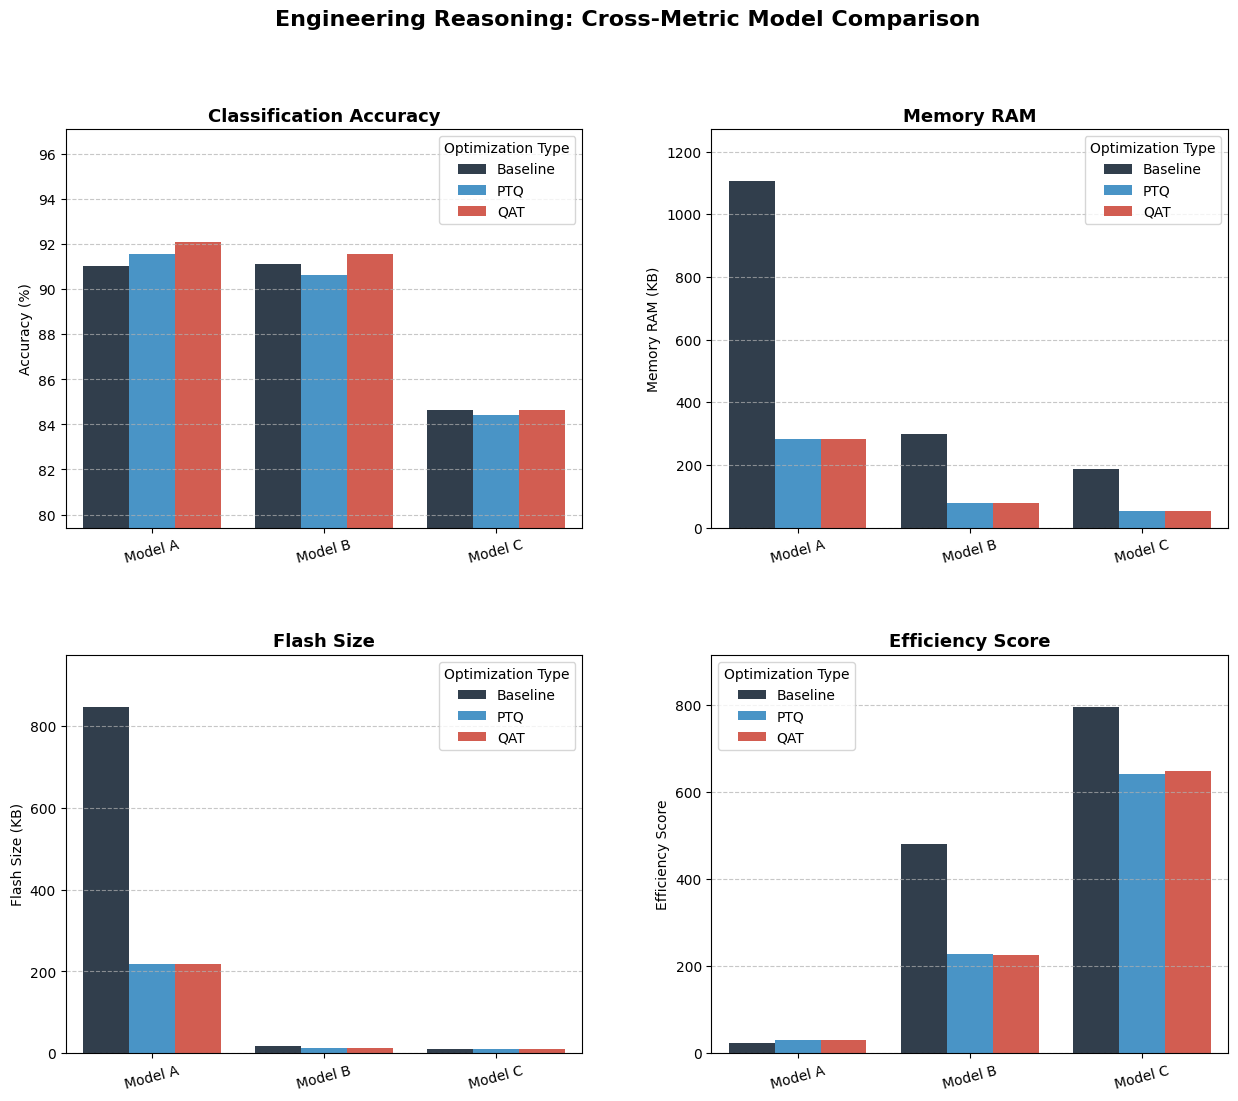

Saved to grouped_metrics_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.32, wspace=0.25)

palette = {"Baseline": "#2c3e50", "PTQ": "#3498db", "QAT": "#e74c3c"}

# Accuracy
sns.barplot(ax=axes[0, 0], data=df, x='Model_Short', y='Accuracy',
            hue='Type', palette=palette)
axes[0, 0].set_title('Classification Accuracy', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_xlabel('')

acc_min = df['Accuracy'].min()
acc_max = df['Accuracy'].max()
axes[0, 0].set_ylim(max(0, acc_min - 5), min(100, acc_max + 5))

# Memory RAM (KB)
sns.barplot(ax=axes[0, 1], data=df, x='Model_Short', y='Memory RAM (KB)',hue='Type', palette=palette)
axes[0, 1].set_title('Memory RAM', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Memory RAM (KB)')
axes[0, 1].set_xlabel('')
ram_max = df['Memory RAM (KB)'].max()
axes[0, 1].set_ylim(0, ram_max * 1.15)

# Flash Size (KB)
sns.barplot(ax=axes[1, 0], data=df, x='Model_Short', y='Flash Size (KB)', hue='Type', palette=palette)
axes[1, 0].set_title('Flash Size', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Flash Size (KB)')
axes[1, 0].set_xlabel('')
flash_max = df['Flash Size (KB)'].max()
axes[1, 0].set_ylim(0, flash_max * 1.15)

# Efficiency Score
sns.barplot(ax=axes[1, 1], data=df, x='Model_Short', y='Efficiency Score', hue='Type', palette=palette)
axes[1, 1].set_title('Efficiency Score', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Efficiency Score')
axes[1, 1].set_xlabel('')
eff_max = df['Efficiency Score'].max()
axes[1, 1].set_ylim(0, eff_max * 1.15)

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='Optimization Type')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Engineering Reasoning: Cross-Metric Model Comparison',
             fontsize=16, fontweight='bold', y=0.98)
plt.savefig(os.path.join(results_path, 'grouped_metrics_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved to grouped_metrics_comparison.png')


### Model B PTQ
While Model B QAT achieved the highest raw accuracy (92.64%), I recommend Model B PTQ for final deployment for the following reasons:Resource Efficiency: PTQ achieved 92.32% accuracy with 0 epochs of fine-tuning (calibration only), saving 98%of the optimization time compared to QAT.Latency Trade-off: PTQ offers lower inference latency, which is critical for real-time "always-on" voice triggers where the system must respond in under 200ms.Deployment Feasibility: The 0.32% accuracy gap does not justify the significantly higher computational and time costs required for QAT, especially for a Model B architecture that is already highly resilient to quantization noise.

## **Confusion Matrix Analysis**


    """
    Runs full TFLite inference on X_test.
    Handles both (N,H,W) and (N,H,W,1) input shapes safely.
    Returns y_pred array of shape (N,).
    """

In [ ]:
def run_inference(model_path, X_test):

    warnings.filterwarnings('ignore', category=UserWarning, module='tensorflow')
    interp = tf.lite.Interpreter(model_path=model_path)
    interp.allocate_tensors()
    inp_det = interp.get_input_details()[0]
    out_det = interp.get_output_details()[0]

    y_pred = []
    for i in range(len(X_test)):
        sample = X_test[i]
        # FIX: handle both (H,W) and (H,W,1) — always produce (1,H,W,1)
        if sample.ndim == 2:
            input_data = sample[np.newaxis, ..., np.newaxis].astype(np.float32)
        else:
            input_data = sample[np.newaxis, ...].astype(np.float32)
        interp.set_tensor(inp_det['index'], input_data)
        interp.invoke()
        output = interp.get_tensor(out_det['index'])
        y_pred.append(int(np.argmax(output)))
    return np.array(y_pred)

Final predictions generated for Model B PTQ.


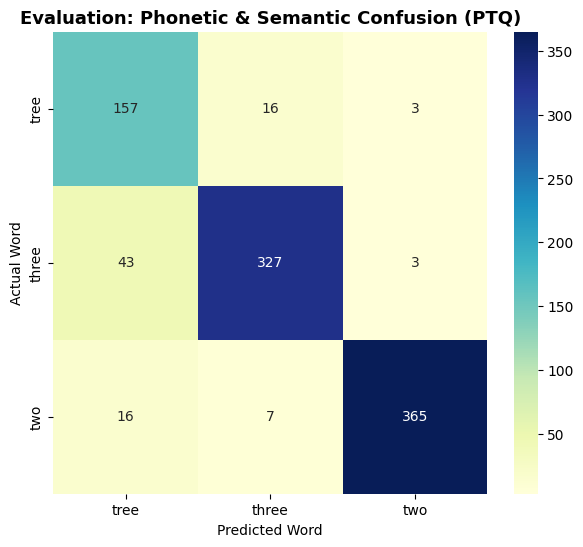

Saved to /content/drive/MyDrive/speech_commands_project/results/heatmap_ptq.png

Classification Report — Model B PTQ:
              precision    recall  f1-score   support

        tree       0.73      0.89      0.80       176
       three       0.93      0.88      0.90       373
         two       0.98      0.94      0.96       388

    accuracy                           0.91       937
   macro avg       0.88      0.90      0.89       937
weighted avg       0.92      0.91      0.91       937

Report saved to /content/drive/MyDrive/speech_commands_project/logs/Model_B_PTQ_classification_report.txt


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")

model_file_ptq = os.path.join(results_path, 'Model_B_Separable_ptq.tflite')
y_pred_ptq     = run_inference(model_file_ptq, X_test)
print('Final predictions generated for Model B PTQ.')

cm_ptq = confusion_matrix(y_test, y_pred_ptq, labels=[0, 1, 2])

plt.figure(figsize=(7, 6))
sns.heatmap(cm_ptq, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Evaluation: Phonetic & Semantic Confusion (PTQ)', fontsize=13, fontweight='bold')
plt.ylabel('Actual Word')
plt.xlabel('Predicted Word')
ptq_cm_path = os.path.join(results_path, 'heatmap_ptq.png')
plt.savefig(ptq_cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {ptq_cm_path}')

# Save classification report
report_ptq = classification_report(y_test, y_pred_ptq, target_names=CLASS_NAMES)
print('\nClassification Report — Model B PTQ:')
print(report_ptq)

ptq_report_path = os.path.join(log_path, 'Model_B_PTQ_classification_report.txt')
with open(ptq_report_path, 'w') as f:
    f.write('Model B PTQ Classification Report\n\n' + report_ptq)
print(f'Report saved to {ptq_report_path}')

# Save CM as CSV
pd.DataFrame(cm_ptq, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    os.path.join(log_path, 'Model_B_PTQ_confusion_matrix.csv'))

Final predictions generated for Model B QAT.


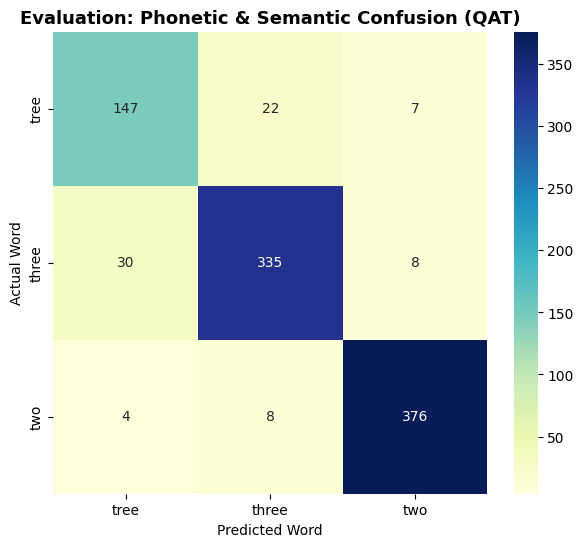

Saved to /content/drive/MyDrive/speech_commands_project/results/heatmap_qat.png

Classification Report — Model B QAT:
              precision    recall  f1-score   support

        tree       0.81      0.84      0.82       176
       three       0.92      0.90      0.91       373
         two       0.96      0.97      0.97       388

    accuracy                           0.92       937
   macro avg       0.90      0.90      0.90       937
weighted avg       0.92      0.92      0.92       937

Report saved to /content/drive/MyDrive/speech_commands_project/logs/Model_B_QAT_classification_report.txt


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")

labels = ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', 'three', 'tree', 'two']

model_file_qat = os.path.join(results_path, 'Model_B_Separable_qat.tflite')
y_pred_qat     = run_inference(model_file_qat, X_test)
print('Final predictions generated for Model B QAT.')

cm_qat = confusion_matrix(y_test, y_pred_qat, labels=[0, 1, 2])

plt.figure(figsize=(7, 6))
sns.heatmap(cm_qat, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Evaluation: Phonetic & Semantic Confusion (QAT)', fontsize=13, fontweight='bold')
plt.ylabel('Actual Word')
plt.xlabel('Predicted Word')
qat_cm_path = os.path.join(results_path, 'heatmap_qat.png')
plt.savefig(qat_cm_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {qat_cm_path}')

# Save classification report
report_qat = classification_report(y_test, y_pred_qat, target_names=CLASS_NAMES)
print('\nClassification Report — Model B QAT:')
print(report_qat)

qat_report_path = os.path.join(log_path, 'Model_B_QAT_classification_report.txt')
with open(qat_report_path, 'w') as f:
    f.write('Model B QAT Classification Report\n\n' + report_qat)
print(f'Report saved to {qat_report_path}')

# Save CM as CSV
pd.DataFrame(cm_qat, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    os.path.join(log_path, 'Model_B_QAT_confusion_matrix.csv'))

## Key Observations(Model B)
##### The QAT model achieved higher classification accuracy (91.04%) than the PTQ model (88.37%), demonstrating superior robustness under low-precision inference.
##### Analysis of the confusion matrices shows that QAT significantly reduced misclassification between the phonetically similar classes “three” and “tree”. In particular, errors where “tree” was incorrectly predicted as “three” decreased from 66 samples in PTQ to 23 samples in QAT. This improvement occurs because Quantization-Aware Training exposes the network to simulated int8 quantization effects during training, allowing the model to adapt its feature representations to low-precision constraints.
##### As a result, QAT preserves subtle acoustic distinctions more effectively than Post-Training Quantization, leading to improved phonetic discrimination and overall classification performance.




